# 01 — VOD 读取与 QC 掩膜（单日示例）

**目标：**
1. 从 MATLAB `.mat`（HDF5）文件中读取 6 通道 VOD（C/X/Ku × H/V）。
2. 读取 QC 字段，并按位解析生成 `vod_qc_flag`（0–6）。
3. 基于 `keep_flags` 生成 `valid_mask`，用于后续掩膜/训练。

**输出：**
- `vod_dict`: dict，包含 6 个 VOD 通道的 (1800, 3600) 矩阵（float32）
- `qc_uint16`: (1800, 3600) QC 原始矩阵（uint16）
- `vod_qc`: (1800, 3600) 质量标识（uint8，0–6）
- `valid_mask`: (1800, 3600) bool，有效像元掩膜


In [4]:
import os, sys
from pathlib import Path
import importlib

# ---------- 1) 找项目根目录（向上寻找 marker：configs/lfmc.yaml + function/） ----------
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start] + list(start.parents):
        if (p / "configs" / "lfmc.yaml").exists() and (p / "function").exists():
            return p
    raise FileNotFoundError(
        f"找不到项目根目录：从 {start} 向上未发现 configs/lfmc.yaml 与 function/。"
    )

cwd = Path.cwd()
PROJECT_ROOT = find_project_root(cwd)

# 把项目根目录加入 sys.path，确保 `import function...` 可用
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

# ---------- 2) 导入你的模块（用模块对象接住） ----------
import function.io.vod_mat as vod_mat
import function.qc.vod_qc as vod_qc

# ---------- 3) 自动更新：每次运行 cell 都 reload ----------
importlib.reload(vod_mat)
importlib.reload(vod_qc)

# ---------- 4) 从“reload 后的模块对象”里取函数（避免旧引用） ----------
find_vod_file = vod_mat.find_vod_file
read_vod_mat  = vod_mat.read_vod_mat

build_vod_qc_array = vod_qc.build_vod_qc_array
build_valid_mask   = vod_qc.build_valid_mask
qc_counts          = vod_qc.qc_counts


PROJECT_ROOT = D:\Python\jupyter\jupyter\LFMCRegressor


## 1. 读取配置（paths.yaml）

我们把所有路径与变量映射写在 `configs/paths.yaml`，这样代码不写死路径，便于复现与迁移。


In [5]:
cfg_path = os.path.join(PROJECT_ROOT, "configs", "paths.yaml")
with open(cfg_path, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

cfg.keys()


dict_keys(['vod', 'qc'])

## 2. 选择日期并定位 VOD 文件

这里先用一个日期做示例（后续可扩展为循环/批处理）。


In [6]:
date = datetime(2002, 6, 1)

vod_file = find_vod_file(date, cfg["vod"])
vod_file


'G:/data/VOD/mat/kuxcVOD/ASC\\MCCA_AMSRE_010D_CCXH_VSM_VOD_Asc_20020601_V0.nc4.mat'

## 3. 读取 VOD 与 QC

函数 `read_vod_mat()` 负责：
- 按 `var_map` 读取 6 个 VOD 通道
- 强制输出为 `(1800, 3600)`（必要时转置）
- 输出 QC 原始数组（uint16）


In [7]:
vod_dict, qc_uint16 = read_vod_mat(vod_file, cfg["vod"])

print("VOD keys:", list(vod_dict.keys()))
print("QC dtype/shape:", qc_uint16.dtype, qc_uint16.shape)


VOD keys: ['tau_Ku_H', 'tau_Ku_V', 'tau_X_H', 'tau_X_V', 'tau_C_H', 'tau_C_V']
QC dtype/shape: uint16 (1800, 3600)


## 4. QC 解析与有效掩膜

我们将 QC（低 8 位）按位解析并生成 `vod_qc_flag`：
- 0: Good  
- 1: Frozen  
- 2: Polarization RFI  
- 3: Medium spectral RFI  
- 4: Severe spectral RFI  
- 5: Snow/Ice > 5%  
- 6: Fill 或任一输入变量为 NaN  

然后根据 `configs/paths.yaml` 的 `keep_flags` 生成 `valid_mask`。


In [8]:
vod_qc = build_vod_qc_array(
    qc_uint16=qc_uint16,
    vod_dict=vod_dict,
    fill_qc_value=cfg["qc"]["fill_qc_value"],
)

valid_mask = build_valid_mask(vod_qc, keep_flags=cfg["qc"]["keep_flags"])

counts = qc_counts(vod_qc)
print("QC counts:", counts)
print("Valid ratio:", float(valid_mask.mean()))


QC counts: {0: 117543, 1: 6383, 2: 71, 3: 5021, 4: 2595, 5: 5544, 6: 6342843}
Valid ratio: 0.01813935185185185


## 5. QC 分布可视化

检查 QC 类别数量是否合理，并查看有效掩膜的空间分布。


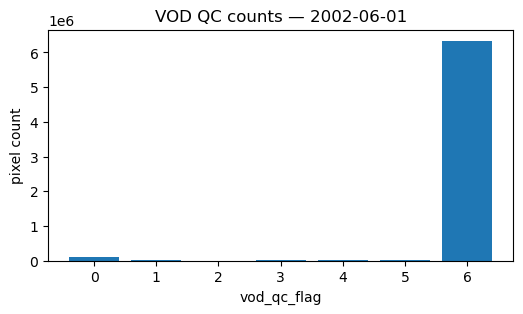

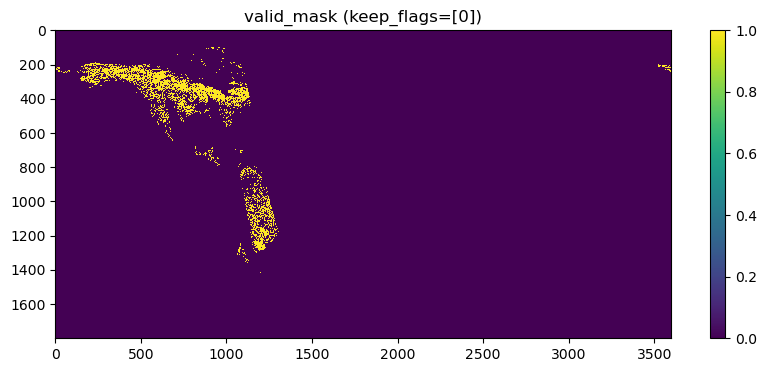

In [9]:
# QC直方图
keys = sorted(counts.keys())
vals = [counts[k] for k in keys]

plt.figure(figsize=(6, 3))
plt.bar(keys, vals)
plt.xlabel("vod_qc_flag")
plt.ylabel("pixel count")
plt.title(f"VOD QC counts — {date.strftime('%Y-%m-%d')}")
plt.show()

# 有效像元掩膜
plt.figure(figsize=(10, 4))
plt.imshow(valid_mask, interpolation="nearest")
plt.title(f"valid_mask (keep_flags={cfg['qc']['keep_flags']})")
plt.colorbar()
plt.show()


## 6. 6 通道 VOD 统计检查（仅有效像元）

对每个通道输出有效像元上的 min/max/mean。
这一步用于快速检查：
- 是否存在整体偏移或异常值
- 是否出现大面积 NaN/极端值


In [10]:
def stats(arr, m):
    v = arr[m]
    return float(np.nanmin(v)), float(np.nanmax(v)), float(np.nanmean(v))

for k, arr in vod_dict.items():
    mn, mx, me = stats(arr, valid_mask)
    print(f"{k:10s} min={mn:.4f} max={mx:.4f} mean={me:.4f}")


tau_Ku_H   min=0.0068 max=5.0263 mean=0.7674
tau_Ku_V   min=0.0000 max=6.2641 mean=0.7612
tau_X_H    min=0.0047 max=3.6153 mean=0.6691
tau_X_V    min=0.0038 max=4.5166 mean=0.6825
tau_C_H    min=0.0134 max=3.7625 mean=0.6063
tau_C_V    min=0.0002 max=4.2002 mean=0.6300


## 代码的小问题：mat文件不够稳定，所以vod部分会重写相关函数。